In [243]:
import pandas as pd

data = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\Gene list\consensus_results.Retroviridae.txt",sep="\t")

In [244]:
from sklearn.preprocessing import normalize

# 標準化後算兩種機器學習的Shapley value的平均
data["RF_mean_nor"] = normalize(
    data[["RF_mean_abs_Score"]],
    axis=0
)

data["XGB_mean_nor"] = normalize(
    data[["XGB_mean_abs_Score"]],
    axis=0
)

data["AVG_mean"] = (data["XGB_mean_nor"] + data["RF_mean_nor"])/2

In [222]:
print(data[["Gene","RF_mean_abs_Score","XGB_mean_abs_Score","RF_mean_nor","XGB_mean_nor","AVG_mean"]].head())

        Gene  RF_mean_abs_Score  XGB_mean_abs_Score  RF_mean_nor  \
0  MIR4444-1           0.000537            0.533627     0.067538   
1     PNPLA2           0.000773            0.057931     0.097226   
2      SCAF1           0.000318            0.101228     0.039956   
3      SPSB1           0.000267            0.032787     0.033602   
4       TRNH           0.000371            0.285063     0.046638   

   XGB_mean_nor  AVG_mean  
0      0.517449  0.292493  
1      0.056174  0.076700  
2      0.098159  0.069058  
3      0.031793  0.032697  
4      0.276421  0.161529  


In [245]:
# 先將想分析的欄位取出來，當作enrichment的ranking，之後可以調整
col = "RF_mean_abs_Score"

rf_rank = data[["Gene",col]]

print(rf_rank.head())

print(len(rf_rank)) # 39376個基因

     Gene  RF_mean_abs_Score
0   NR4A3           0.003514
1   CXCL2           0.001526
2    ASTL           0.002337
3  NAP1L5           0.001146
4  TNFSF9           0.001159
39376


In [246]:
# 很多基因的數值為0

rf_rank = rf_rank.loc[rf_rank[col] != 0,:]

print(len(rf_rank)) 

6380


In [247]:
rf_rank.columns = ["gene", "score"] # 換col名稱 不確定需不需要

rf_rank = rf_rank.sort_values(
    by="score",
    ascending=False
)

print(rf_rank.head())

      gene     score
0    NR4A3  0.003514
2     ASTL  0.002337
1    CXCL2  0.001526
107  DUSP8  0.001362
23   NRARP  0.001258


In [248]:
# 取出排名前50的基因
rf_rank_top_100 = rf_rank.iloc[0:50,0:2] 

print(rf_rank_top_100.head())

      gene     score
0    NR4A3  0.003514
2     ASTL  0.002337
1    CXCL2  0.001526
107  DUSP8  0.001362
23   NRARP  0.001258


In [249]:
rf_gene_list = rf_rank_top_100["gene"].tolist() # 可以做OSA
print(rf_gene_list[:5])

['NR4A3', 'ASTL', 'CXCL2', 'DUSP8', 'NRARP']


In [250]:
# Pathway database
db = "GO_Biological_Process_2023"

import gseapy as gp

# 先做OSA
res = gp.enrichr(
    gene_list=rf_gene_list, 
    gene_sets=db
)

# 再做GSEA
res_2 = gp.prerank(
    rnk=rf_rank,
    gene_sets=db,
    permutation_num=1000,
    seed=123,
    outdir=None
)

In [229]:
print(res.results.sort_values(
    by="Adjusted P-value",
    ascending=True
).head())

                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   

                                                Term Overlap   P-value  \
0  Positive Regulation Of TORC1 Signaling (GO:190...    3/27  0.000041   
1  Positive Regulation Of TOR Signaling (GO:0032008)    3/47  0.000221   
2         Regulation Of TORC1 Signaling (GO:1903432)    3/50  0.000265   
3          mRNA Splice Site Recognition (GO:0006376)    2/29  0.002382   
4  Small GTPase Mediated Signal Transduction (GO:...   3/112  0.002767   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.012325            0                     0   52.994681   
1          0.026438            0                     0   28.877176   
2          0.026438            0                     0   27.029878   
3          0.162467            0                     0   30.745370   
4     

In [230]:
ora_df = res.results.copy()


# 取顯著 pathway
sig_df = ora_df[
    ora_df["Adjusted P-value"] < 0.05
].copy()


# 依顯著性排序
sig_df = sig_df.sort_values(
    "Adjusted P-value",
    ascending=True
)


print(sig_df.head())
len(sig_df)

                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   

                                                Term Overlap   P-value  \
0  Positive Regulation Of TORC1 Signaling (GO:190...    3/27  0.000041   
1  Positive Regulation Of TOR Signaling (GO:0032008)    3/47  0.000221   
2         Regulation Of TORC1 Signaling (GO:1903432)    3/50  0.000265   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.012325            0                     0   52.994681   
1          0.026438            0                     0   28.877176   
2          0.026438            0                     0   27.029878   

   Combined Score               Genes  
0      535.064695  OTUD5;RNF167;RRAGA  
1      243.120119  OTUD5;RNF167;RRAGA  
2      222.585361  OTUD5;RNF167;RRAGA  


3

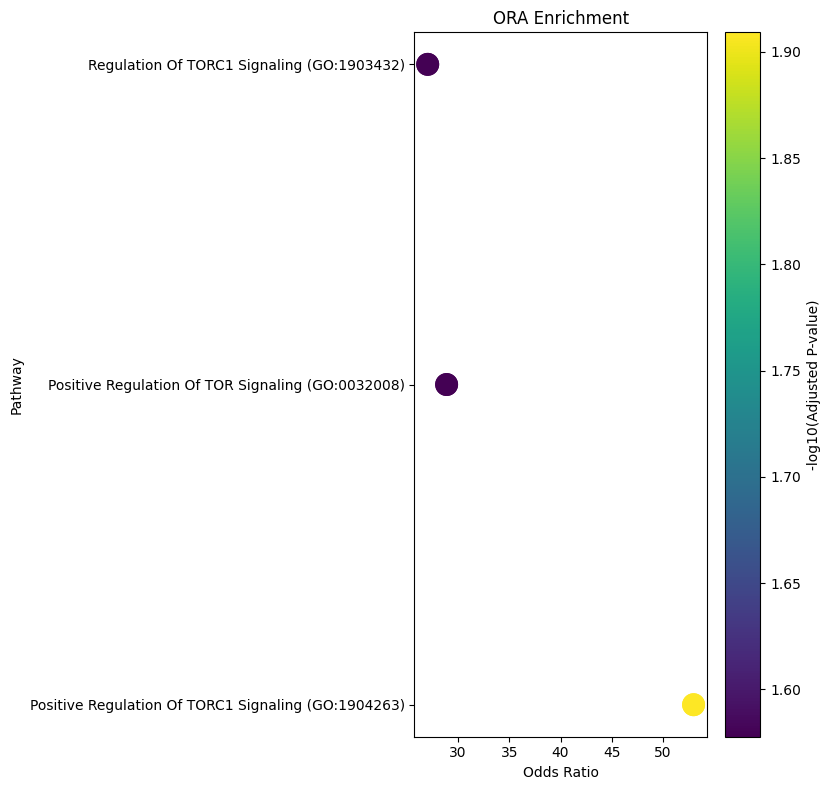

In [231]:
import numpy as np
import matplotlib.pyplot as plt


plot_df = sig_df.copy()


# overlap gene數量
plot_df["Gene_count"] = (
    plot_df["Overlap"]
    .str.split("/")
    .str[0]
    .astype(int)
)


# -log10 FDR
plot_df["-log10(FDR)"] = (
    -np.log10(plot_df["Adjusted P-value"])
)


plt.figure(figsize=(8,8))


plt.scatter(
    plot_df["Odds Ratio"],
    plot_df["Term"],
    s=plot_df["Gene_count"]*80,
    c=plot_df["-log10(FDR)"],
)

scatter = plt.scatter(
    plot_df["Odds Ratio"],
    plot_df["Term"],
    s=plot_df["Gene_count"]*80,
    c=plot_df["-log10(FDR)"],
    cmap="viridis"
)

# 加入colorbar
cbar = plt.colorbar(scatter)

cbar.set_label(
    "-log10(Adjusted P-value)"
)

plt.xlabel(
    "Odds Ratio"
)

plt.ylabel(
    "Pathway"
)

plt.title(
    "ORA Enrichment"
)


plt.tight_layout()

plt.show()

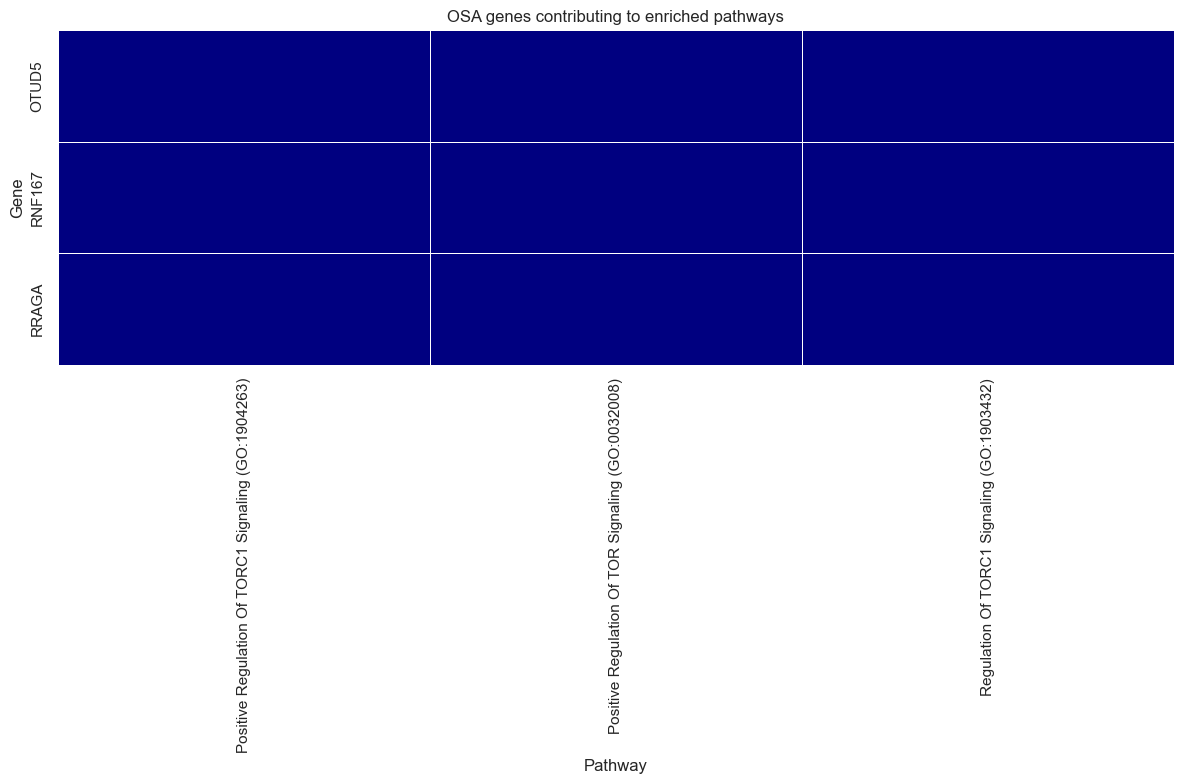

In [238]:
import seaborn as sns


top_pathway = sig_df


# 收集gene

all_genes = set()

for genes in top_pathway["Genes"]:

    all_genes.update(
        genes.split(";")
    )


all_genes = sorted(all_genes)



matrix = pd.DataFrame(
    0,
    index=all_genes,
    columns=top_pathway["Term"]
)



for _, row in top_pathway.iterrows():

    pathway = row["Term"]

    genes = row["Genes"].split(";")

    for gene in genes:

        matrix.loc[
            gene,
            pathway
        ] = 1


plt.figure(
    figsize=(12,8)
)


from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "navy"])

sns.heatmap(
    matrix,
    cmap=cmap,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar=False
)

plt.xlabel(
    "Pathway"
)

plt.ylabel(
    "Gene"
)


plt.title(
    "OSA genes contributing to enriched pathways"
)


plt.tight_layout()

plt.show()

In [251]:
print(res_2.res2d.sort_values(
    by="FDR q-val",
    ascending=True
).head())

      Name                                               Term        ES  \
5  prerank  Positive Regulation Of Leukocyte Mediated Cyto...  0.898526   
7  prerank  Positive Regulation Of T Cell Mediated Immunit...  0.909436   
4  prerank  Cellular Response To Lipopolysaccharide (GO:00...  0.879560   
8  prerank  Regulation Of Interleukin-6 Production (GO:003...  0.885028   
6  prerank    Regulation Of T Cell Proliferation (GO:0042129)  0.904227   

        NES  NOM p-val  FDR q-val  FWER p-val Tag % Gene %  \
5  1.680676   0.000000   0.040278       0.161  3/18  2.48%   
7  1.668266   0.002043   0.044314       0.205  3/15  2.48%   
4  1.682519   0.000000   0.046336       0.154  5/27  1.52%   
8  1.662132   0.003006   0.047047       0.230  5/20  2.73%   
6  1.669139   0.000000   0.049361       0.201  4/16  3.34%   

                  Lead_genes  
5          IL12A;ULBP1;ULBP2  
7          IL12A;ULBP1;ULBP2  
4  CXCL2;IL1A;IL6;IL10;CXCL3  
8   IL1A;IL6;IL10;IFNG;F2RL1  
6       TNFSF9;IL6;IL

In [252]:
sig_gsea = res_2.res2d[
    res_2.res2d["FDR q-val"] < 0.25
]

sig_gsea = sig_gsea.sort_values(
    by="FDR q-val",
    ascending=True
)

print(sig_gsea)
len(sig_gsea)

       Name                                               Term        ES  \
5   prerank  Positive Regulation Of Leukocyte Mediated Cyto...  0.898526   
7   prerank  Positive Regulation Of T Cell Mediated Immunit...  0.909436   
4   prerank  Cellular Response To Lipopolysaccharide (GO:00...  0.879560   
8   prerank  Regulation Of Interleukin-6 Production (GO:003...  0.885028   
6   prerank    Regulation Of T Cell Proliferation (GO:0042129)  0.904227   
3   prerank  Cellular Response To Molecule Of Bacterial Ori...  0.886103   
9   prerank        Response To Lipopolysaccharide (GO:0032496)  0.865614   
2   prerank  Cellular Response To Hormone Stimulus (GO:0032...  0.894096   
10  prerank  Regulation Of Tyrosine Phosphorylation Of STAT...  0.878504   
11  prerank  Positive Regulation Of Epithelial Cell Prolife...  0.873850   
13  prerank  Regulation Of Epithelial Cell Proliferation (G...  0.889294   
15  prerank  Positive Regulation Of Cell Adhesion (GO:0045785)  0.860137   
1   prerank 

46

In [203]:
Lead_genes = sig_gsea["Lead_genes"].to_list()

Lead_genes[1]

'SLC38A5;SLC38A10;SLC6A15;SLC38A11;SLC38A7;SLC38A1;SLC7A11;SLC43A2;SLC3A1;SH3BP4;SLC7A5;SLC7A3;SLC1A5;SLC7A9;SLC7A14;SLC38A4;SLC6A6;SLC36A1;SLC32A1;SLC7A10;SLC7A2;SLC38A6;SLC6A12;SLC7A8'

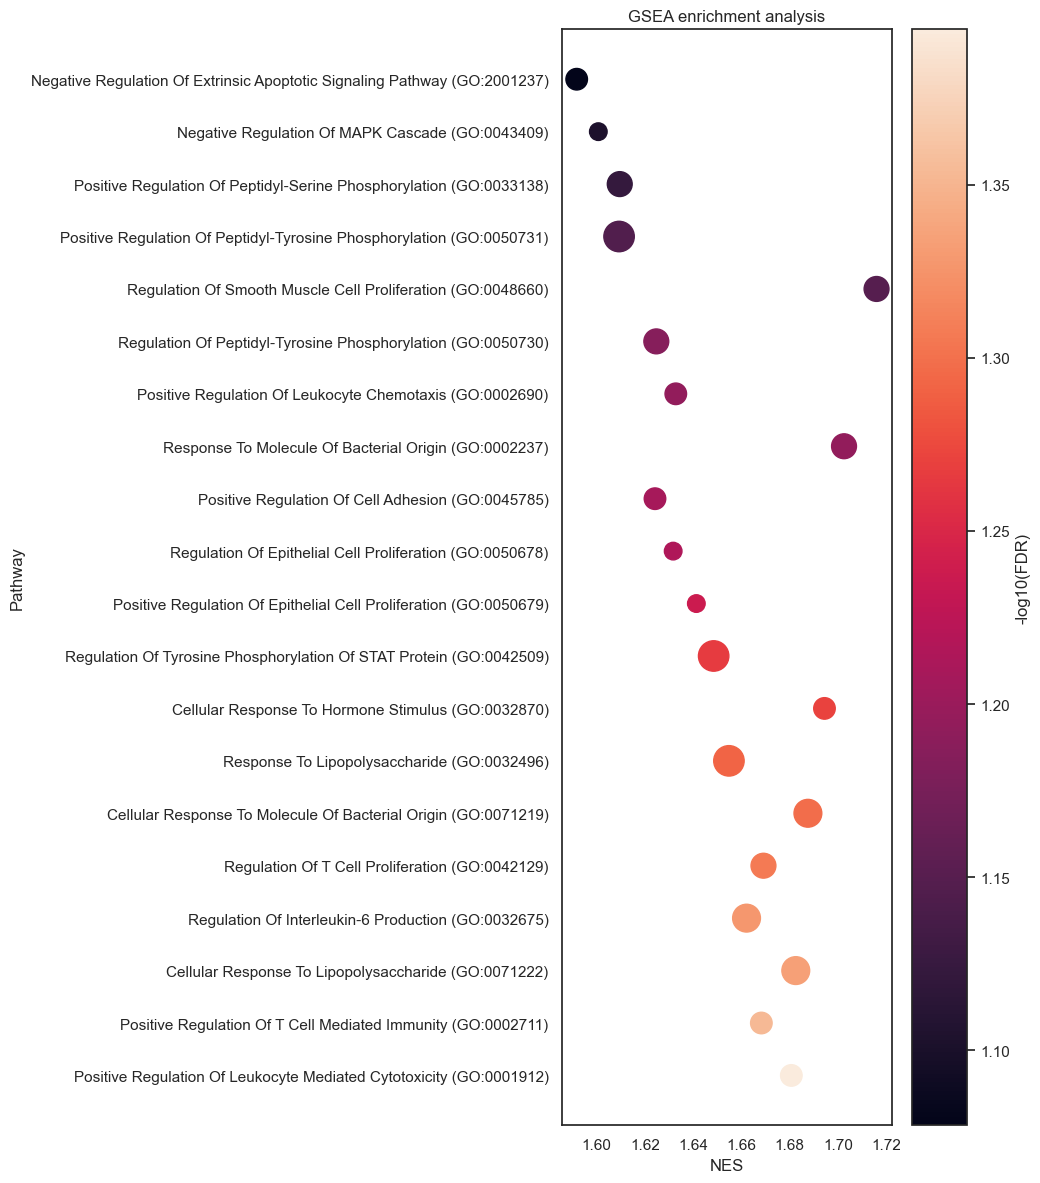

In [253]:
import matplotlib.pyplot as plt
import numpy as np


plot_df = sig_gsea.head(20).copy()


plot_df["Tag_count"] = (
    plot_df["Tag %"]
    .str.split("/")
    .str[0]
    .astype(int)
)


plt.figure(figsize=(10,12))


scatter = plt.scatter(
    plot_df["NES"],
    plot_df["Term"],
    s=plot_df["Tag_count"]*80,
    c=-np.log10(plot_df["FDR q-val"])
)


plt.colorbar(
    scatter,
    label="-log10(FDR)"
)


plt.xlabel(
    "NES"
)

plt.ylabel(
    "Pathway"
)


plt.title(
    "GSEA enrichment analysis"
)


plt.tight_layout()

plt.show()

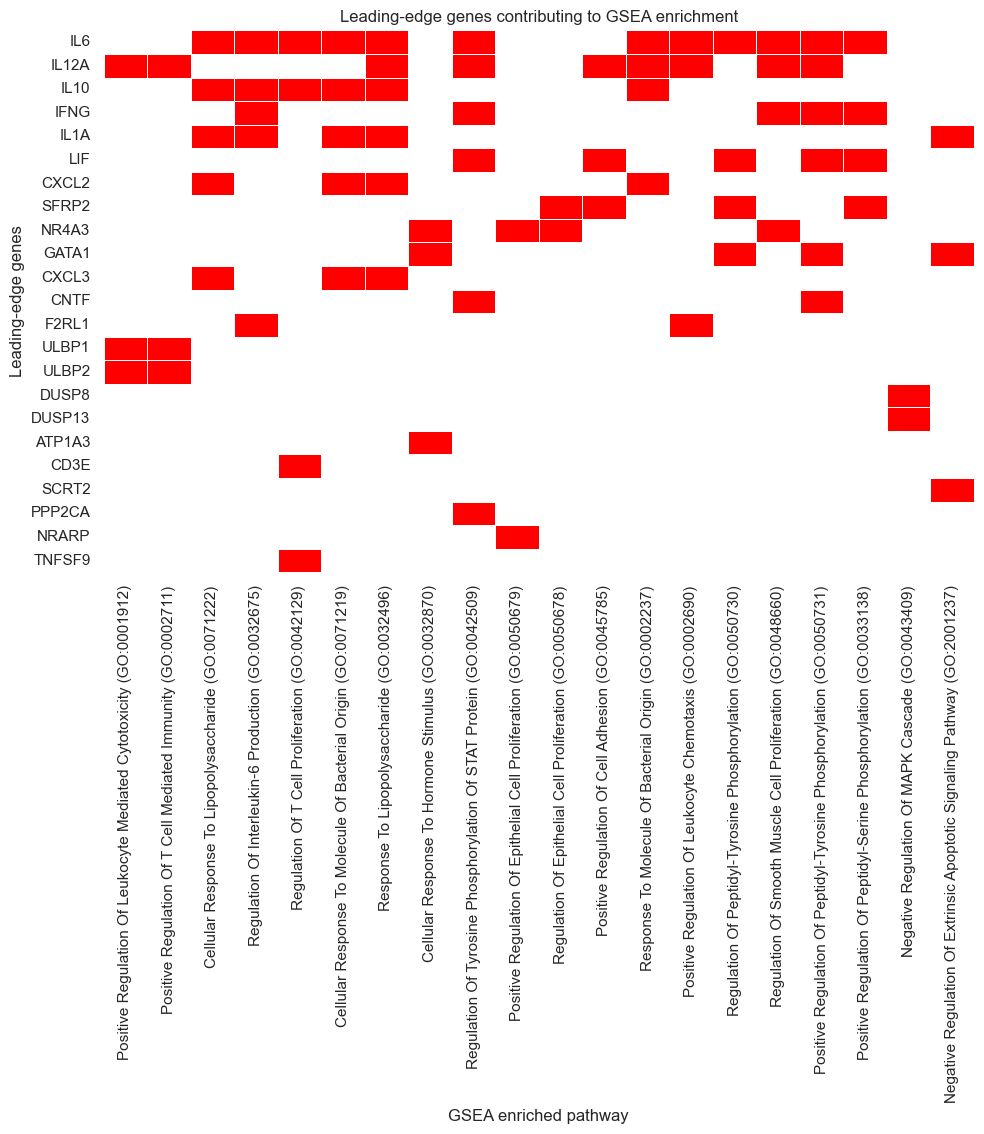

In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap


top_pathway = sig_gsea.head(20).copy()


# =========================
# 收集 leading-edge genes
# =========================

all_genes = set()


for genes in top_pathway["Lead_genes"]:

    all_genes.update(
        genes.split(";")
    )


all_genes = sorted(all_genes)



# =========================
# 建立 0/1 matrix
# =========================

matrix = pd.DataFrame(
    0,
    index=all_genes,
    columns=top_pathway["Term"]
)



for _, row in top_pathway.iterrows():

    pathway = row["Term"]

    genes = row["Lead_genes"].split(";")


    for gene in genes:

        matrix.loc[
            gene,
            pathway
        ] = 1



# =========================
# gene排序
# 出現越多pathway越上面
# =========================

matrix = matrix.loc[
    matrix.sum(axis=1)
    .sort_values(ascending=False)
    .index
]



# =========================
# 畫binary heatmap
# =========================

plt.figure(
    figsize=(
        max(8, len(matrix.columns)*0.5),
        max(8, len(matrix.index)*0.5)
    )
)


cmap = ListedColormap(
    ["white", "red"]
)


sns.heatmap(
    matrix,
    cmap=cmap,
    linewidths=0.5,
    cbar=False
)


plt.xlabel(
    "GSEA enriched pathway"
)


plt.ylabel(
    "Leading-edge genes"
)


plt.title(
    "Leading-edge genes contributing to GSEA enrichment"
)


plt.tight_layout()

plt.show()